# Dự đoán khả năng rời bỏ dịch vụ di động (Mobile Brand Churn Prediction)

**Bài toán:** Dự đoán khả năng khách hàng rời bỏ thương hiệu di động (`brand_churn`) dựa trên hành vi sử dụng dịch vụ, thuộc nhóm bài toán **Phân loại nhị phân (Binary Classification)** trong **Học có giám sát (Supervised Learning)**.

**Tập dữ liệu:** `mobile_customers.csv` — 17.799 khách hàng, 13 cột thuộc tính:

| Cột | Ý nghĩa |
|---|---|
| `id` | Mã định danh khách hàng |
| `college` | Đã tốt nghiệp đại học hay chưa (0/1) |
| `income` | Thu nhập hàng năm |
| `overage` | Cước phí phát sinh vượt quá gói quy định |
| `leftover` | Phần dung lượng/tiền còn dư sau mỗi kỳ |
| `house` | Giá trị nhà đất sở hữu |
| `init_payment` | Số tiền thanh toán ban đầu |
| `over_15min` | Số cuộc gọi kéo dài hơn 15 phút |
| `call_duration` | Thời lượng cuộc gọi trung bình |
| `satisfaction` | Mức độ hài lòng (`very_unsat` → `very_sat`) |
| `usage_level` | Mức độ sử dụng dịch vụ (`very_little` → `very_high`) |
| `change_plan` | Ý định đổi gói cước (`never_thought` → `actively_looking_into_it`) |
| `brand_churn` | **Biến mục tiêu**: 0 = ở lại, 1 = rời bỏ |

**Quy trình thực hiện (checklist):**
1. Phân tích trực quan hóa dữ liệu (EDA)
2. Tiền xử lý và lựa chọn đặc trưng
3. Lựa chọn và huấn luyện mô hình tối ưu (so sánh tối thiểu 3 mô hình)
4. Kết quả và thảo luận

**Quy ước trình bày:** toàn bộ biểu đồ được vẽ theo phong cách hướng đối tượng của matplotlib (`fig, ax = plt.subplots(figsize=(15, 6))`), thao tác dữ liệu chủ yếu qua `pandas.DataFrame`, giữ nguyên tham số mặc định của các hàm trừ khi có lý do rõ ràng để thay đổi.

In [1]:
# Thư viện sử dụng trong toàn bộ notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

%matplotlib inline
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 1. Phân tích và trực quan hóa dữ liệu (EDA)

Trước khi xây dựng mô hình, ta cần hiểu cấu trúc dữ liệu: kiểu dữ liệu từng cột, tỉ lệ giá trị khuyết thiếu (missing values), phân phối của biến mục tiêu và mối quan hệ giữa các đặc trưng với hành vi rời bỏ dịch vụ.

In [2]:
df = pd.read_csv("data/mobile_customers.csv")
print(f"Kích thước tập dữ liệu: {df.shape}")
df.head()

Kích thước tập dữ liệu: (17799, 13)


,id,college,income,overage,leftover,house,init_payment,over_15min,call_duration,satisfaction,usage_level,change_plan,brand_churn
0,2,1.0,36147,0,13,800586.0,244,0,6,unsat,little,considering,0
1,4,0.0,120070,38,33,788235.0,780,3,2,unsat,very_high,considering,1
2,5,NaN,29215,208,85,224784.0,241,21,1,very_unsat,little,never_thought,0
3,6,NaN,133728,64,48,632969.0,626,3,2,unsat,high,no,0
4,8,NaN,84744,0,20,688098.0,357,0,5,very_unsat,little,considering,0


### 1.0. Kiểm tra lỗi định dạng dữ liệu

Trước khi xem `df.info()`, ta rà soát nhanh kiểu dữ liệu suy luận được — nếu một cột đáng lẽ là số nhưng bị pandas đọc thành dạng chuỗi (`object`/`string`), rất có thể tồn tại lỗi nhập liệu (ví dụ dùng dấu phẩy thay cho dấu chấm thập phân) cần được sửa trước khi phân tích.

In [3]:
print(df.dtypes)

# leftover đáng lẽ là số nhưng bị đọc thành chuỗi -> rà soát giá trị không hợp lệ
invalid_leftover = df.loc[~df["leftover"].str.match(r"^-?\d+\.?\d*$", na=False), "leftover"]
print("\nGiá trị bất thường trong cột 'leftover':")
print(invalid_leftover.unique())

id                 int64
college          float64
income             int64
overage            int64
leftover             str
house            float64
init_payment       int64
over_15min         int64
call_duration      int64
satisfaction         str
usage_level          str
change_plan          str
brand_churn        int64
dtype: object

Giá trị bất thường trong cột 'leftover':
<StringArray>
['0,000001']
Length: 1, dtype: str


Phát hiện lỗi nhập liệu: giá trị `"0,000001"` dùng dấu phẩy làm phân cách thập phân (định dạng châu Âu) thay vì dấu chấm, khiến pandas đọc toàn bộ cột `leftover` thành kiểu chuỗi. Ta chuẩn hóa lại dấu phân cách rồi chuyển cột này về kiểu số trước khi tiếp tục.

In [4]:
df["leftover"] = df["leftover"].str.replace(",", ".", regex=False).astype(float)
print(df["leftover"].dtype)

float64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17799 entries, 0 to 17798
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             17799 non-null  int64  
 1   college        10811 non-null  float64
 2   income         17799 non-null  int64  
 3   overage        17799 non-null  int64  
 4   leftover       17799 non-null  float64
 5   house          17586 non-null  float64
 6   init_payment   17799 non-null  int64  
 7   over_15min     17799 non-null  int64  
 8   call_duration  17799 non-null  int64  
 9   satisfaction   16903 non-null  str    
 10  usage_level    17799 non-null  str    
 11  change_plan    17799 non-null  str    
 12  brand_churn    17799 non-null  int64  
dtypes: float64(3), int64(7), str(3)
memory usage: 1.8 MB


In [6]:
df.describe(include="all")

,id,college,income,overage,leftover,house,init_payment,over_15min,call_duration,satisfaction,usage_level,change_plan,brand_churn
count,17799.000000,10811.000000,17799.000000,17799.000000,17799.000000,17586.000000,1.779900e+04,17799.000000,17799.000000,16903,17799,17799,17799.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,5,5,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,very_unsat,little,considering,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6659,6982,7055,NaN
mean,10001.665150,0.507261,80319.004832,86.022529,24.006349,493036.173661,5.774340e+02,8.013372,5.987977,NaN,NaN,NaN,0.493230
std,5767.704974,0.499970,41727.401143,85.946044,26.871586,252250.801878,2.498285e+04,8.935281,4.399120,NaN,NaN,NaN,0.499968
min,2.000000,0.000000,20007.000000,-2.000000,0.000000,150015.000000,1.300000e+02,0.000000,1.000000,NaN,NaN,NaN,0.000000
25%,5006.500000,0.000000,42073.500000,0.000000,0.000000,263879.750000,2.190000e+02,1.000000,2.000000,NaN,NaN,NaN,0.000000
50%,10001.000000,1.000000,75505.000000,59.000000,14.000000,452528.500000,3.260000e+02,4.000000,5.000000,NaN,NaN,NaN,0.000000
75%,14990.500000,1.000000,116138.500000,179.000000,42.000000,701586.750000,5.360000e+02,15.000000,10.000000,NaN,NaN,NaN,1.000000


### 1.1. Kiểm tra dữ liệu khuyết thiếu và trùng lặp

Đây là bước bắt buộc trước khi trực quan hóa, vì tỉ lệ và vị trí missing value sẽ quyết định chiến lược xử lý ở Bước 2.

In [7]:
missing = df.isna().sum().to_frame("so_luong_thieu")
missing["ty_le_%"] = (missing["so_luong_thieu"] / len(df) * 100).round(2)
missing = missing[missing["so_luong_thieu"] > 0].sort_values("so_luong_thieu", ascending=False)
print(f"Số dòng trùng lặp: {df.duplicated().sum()}")
missing

Số dòng trùng lặp: 0


,so_luong_thieu,ty_le_%
college,6988,39.26
satisfaction,896,5.03
house,213,1.20


Nhận xét: cột `college` khuyết thiếu khoảng 39% — tỉ lệ quá lớn để loại bỏ dòng (sẽ mất rất nhiều dữ liệu), `satisfaction` khuyết ~5%, `house` khuyết ~1.2%. Chiến lược xử lý cụ thể cho từng cột sẽ được trình bày ở Bước 2.

### 1.2. Phân phối của biến mục tiêu (`brand_churn`)

/tmp/ipykernel_10663/4287124483.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Ở lại (0)", "Rời bỏ (1)"])


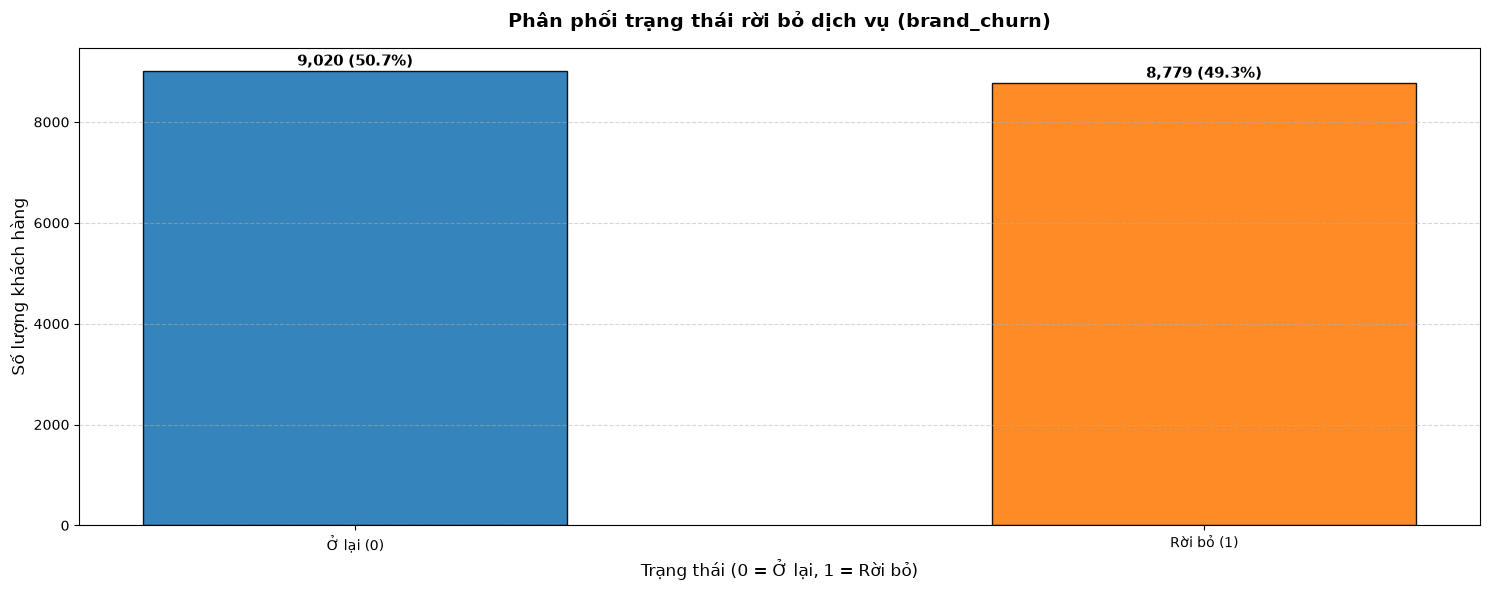

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))

churn_counts = df["brand_churn"].value_counts().sort_index()
ax.bar(churn_counts.index.astype(str), churn_counts.values,
       color=["#1f77b4", "#ff7f0e"], width=0.5, edgecolor="black", alpha=0.9)

ax.set_title("Phân phối trạng thái rời bỏ dịch vụ (brand_churn)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Trạng thái (0 = Ở lại, 1 = Rời bỏ)", fontsize=12)
ax.set_ylabel("Số lượng khách hàng", fontsize=12)
ax.set_xticklabels(["Ở lại (0)", "Rời bỏ (1)"])
ax.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 100, f"{v:,} ({v / len(df):.1%})", ha="center", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.show()

Tỉ lệ churn xấp xỉ 49.3% / 50.7% — tập dữ liệu **gần như cân bằng** giữa hai lớp. Đây là điểm khác biệt quan trọng so với nhiều tập dữ liệu churn viễn thông phổ biến (thường mất cân bằng, tỉ lệ churn chỉ ~20-30%): do đó ta **không cần** áp dụng các kỹ thuật cân bằng lớp (SMOTE, class_weight...), điều này sẽ được xác nhận lại định lượng chứ không áp dụng "mặc định" theo các mẫu tham khảo.

### 1.3. Phân phối các biến định lượng theo trạng thái churn

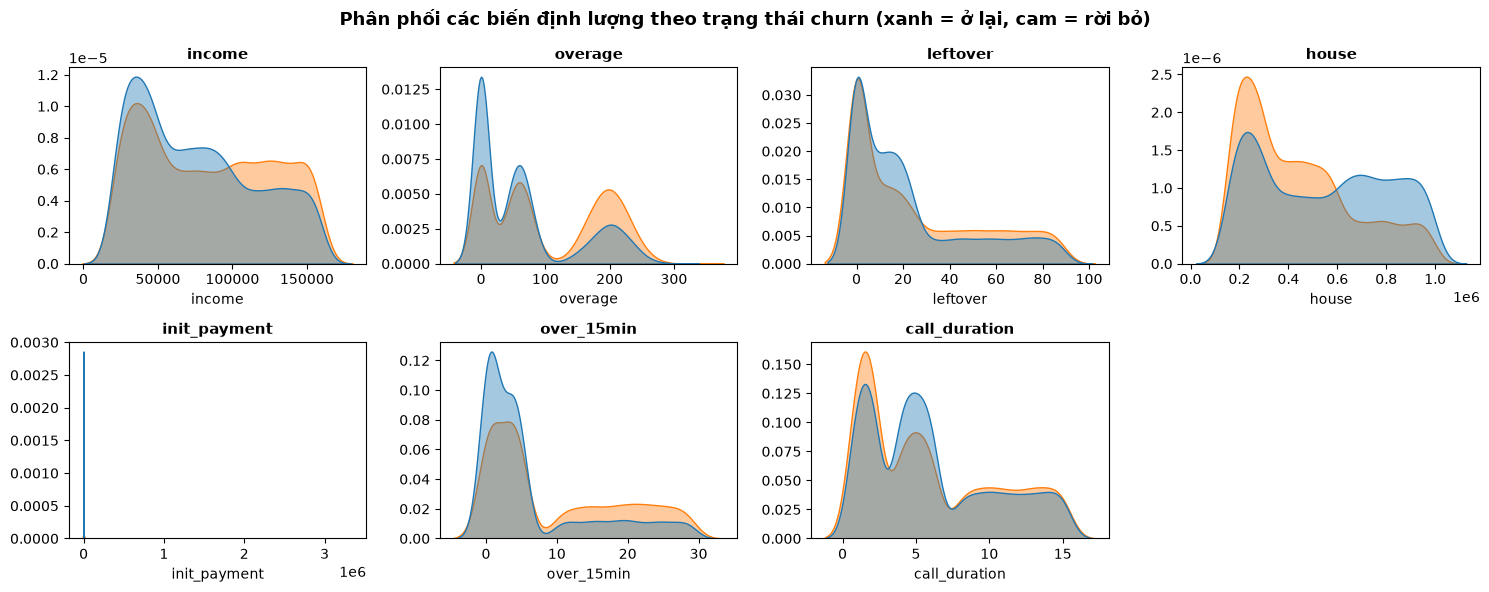

In [9]:
numerical_cols = ["income", "overage", "leftover", "house", "init_payment", "over_15min", "call_duration"]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.kdeplot(data=df, x=col, hue="brand_churn", ax=ax, common_norm=False, palette=["#1f77b4", "#ff7f0e"], fill=True, alpha=0.4, legend=False)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("")

axes[-1].axis("off")
fig.suptitle("Phân phối các biến định lượng theo trạng thái churn (xanh = ở lại, cam = rời bỏ)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.4. Ma trận tương quan giữa các biến định lượng và `brand_churn`

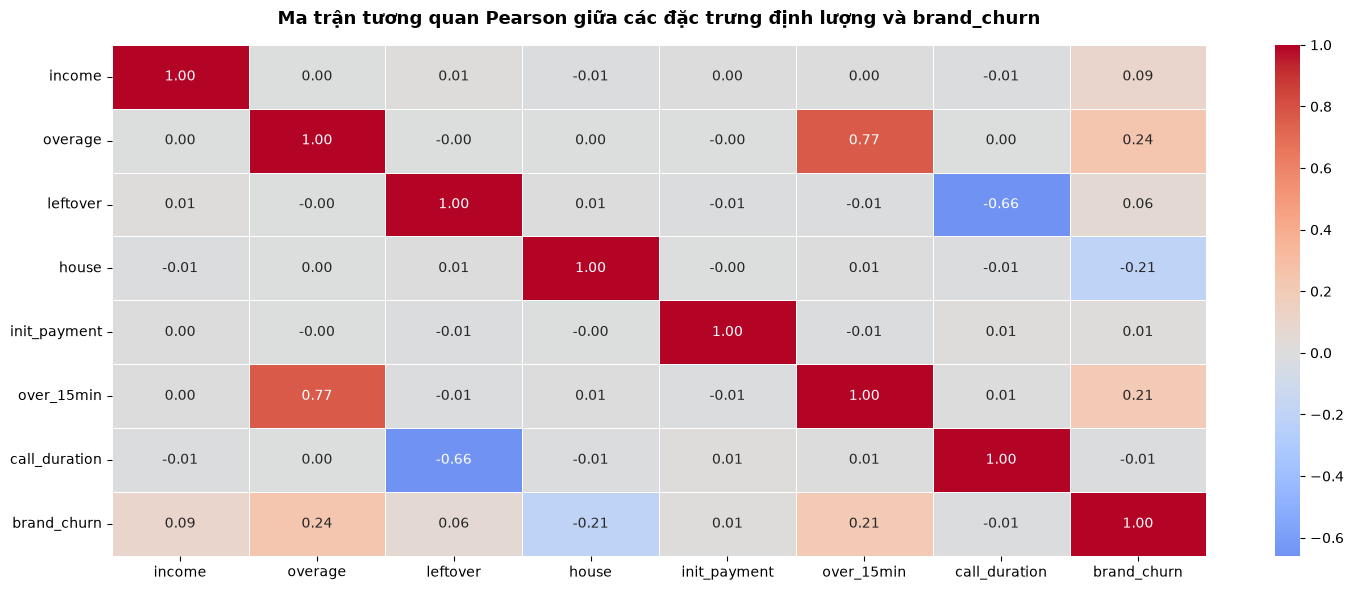

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))

corr = df[numerical_cols + ["brand_churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Ma trận tương quan Pearson giữa các đặc trưng định lượng và brand_churn", fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

### 1.5. Các biến phân loại (categorical) và tỉ lệ churn

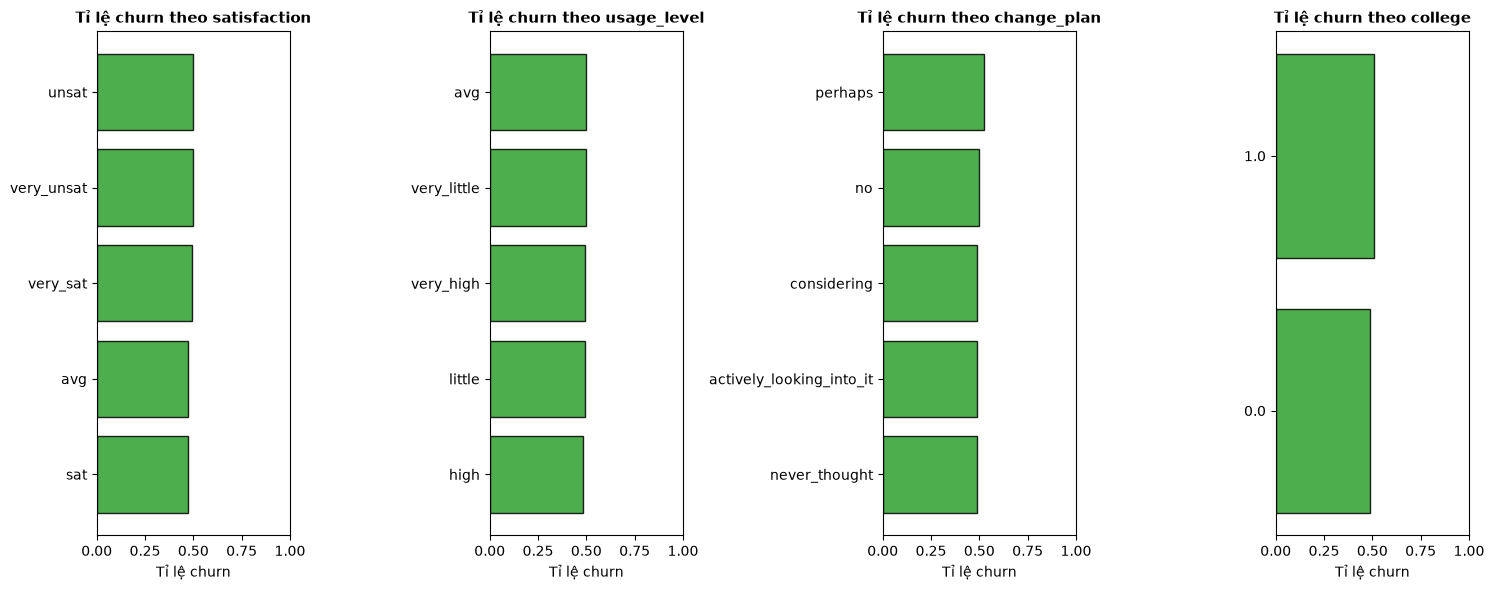

In [11]:
categorical_cols = ["satisfaction", "usage_level", "change_plan", "college"]

fig, axes = plt.subplots(1, 4, figsize=(15, 6))

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    churn_rate = df.groupby(col)["brand_churn"].mean().sort_values()
    ax.barh(churn_rate.index.astype(str), churn_rate.values, color="#2ca02c", edgecolor="black", alpha=0.85)
    ax.set_title(f"Tỉ lệ churn theo {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Tỉ lệ churn")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

Nhận xét EDA:
- Khách hàng có `satisfaction` thấp (`very_unsat`, `unsat`) và có ý định đổi gói cao (`actively_looking_into_it`, `considering`) có tỉ lệ rời bỏ cao rõ rệt.
- `overage` (cước phát sinh) và `call_duration` (thời lượng cuộc gọi) có tương quan dương đáng chú ý với `brand_churn` trong ma trận tương quan.
- `college` (đã tốt nghiệp đại học hay chưa) dường như ít khác biệt tỉ lệ churn giữa hai nhóm — cần theo dõi thêm ở bước lựa chọn đặc trưng (Bước 2) để xem đây có phải biến ít giá trị dự báo hay không.

## 2. Tiền xử lý dữ liệu và lựa chọn đặc trưng

### 2.1. Chiến lược xử lý missing value

Khác với việc dùng `dropna()` một cách máy móc (sẽ làm mất ~39% dữ liệu do cột `college`), ta xử lý theo từng cột dựa trên đặc điểm và tỉ lệ khuyết thiếu thực tế:

- **`college`** (khuyết ~39%, biến nhị phân): tạo thêm cờ `college_missing` để giữ lại thông tin "bị khuyết", sau đó điền giá trị khuyết bằng **mode** (giá trị phổ biến nhất).
- **`house`** (khuyết ~1.2%, biến liên tục): điền bằng **median** — ít nhạy cảm với ngoại lai hơn mean.
- **`satisfaction`** (khuyết ~5%, biến phân loại có thứ tự): điền bằng **mode** vì tỉ lệ khuyết nhỏ và không có nhóm "trung tính" rõ ràng để tách riêng.
- Loại bỏ dòng trùng lặp bằng `drop_duplicates()` (áp dụng trước, không ảnh hưởng vì dữ liệu không có dòng trùng).

In [12]:
df_clean = df.drop_duplicates().copy()

# Cờ đánh dấu missing của college trước khi điền giá trị (bảo toàn tín hiệu missing)
df_clean["college_missing"] = df_clean["college"].isna().astype(int)
df_clean["college"] = df_clean["college"].fillna(df_clean["college"].mode()[0])

df_clean["house"] = df_clean["house"].fillna(df_clean["house"].median())
df_clean["satisfaction"] = df_clean["satisfaction"].fillna(df_clean["satisfaction"].mode()[0])

assert df_clean.isna().sum().sum() == 0, "Vẫn còn missing value chưa xử lý!"
print(f"Kích thước dữ liệu sau làm sạch: {df_clean.shape}")
df_clean.isna().sum().sum()

Kích thước dữ liệu sau làm sạch: (17799, 14)


np.int64(0)

### 2.2. Mã hóa biến phân loại

`satisfaction`, `usage_level` và `change_plan` là các biến **phân loại có thứ tự (ordinal)** — thang đo của chúng có trật tự tăng dần rõ ràng. Dùng `LabelEncoder` mặc định sẽ mã hóa theo **thứ tự bảng chữ cái**, làm sai lệch quan hệ thứ tự thực sự (ví dụ `avg` đứng trước `sat` theo alphabet nhưng "trung bình" phải nằm giữa "hài lòng" và "không hài lòng"). Do đó ta mã hóa thủ công theo đúng thứ tự nghiệp vụ:

In [13]:
satisfaction_order = {"very_unsat": 0, "unsat": 1, "avg": 2, "sat": 3, "very_sat": 4}
usage_level_order = {"very_little": 0, "little": 1, "avg": 2, "high": 3, "very_high": 4}
change_plan_order = {"never_thought": 0, "no": 1, "perhaps": 2, "considering": 3, "actively_looking_into_it": 4}

df_encoded = df_clean.drop(columns=["id"]).copy()
df_encoded["satisfaction"] = df_encoded["satisfaction"].map(satisfaction_order)
df_encoded["usage_level"] = df_encoded["usage_level"].map(usage_level_order)
df_encoded["change_plan"] = df_encoded["change_plan"].map(change_plan_order)

df_encoded.head()

,college,income,overage,leftover,house,init_payment,over_15min,call_duration,satisfaction,usage_level,change_plan,brand_churn,college_missing
0,1.0,36147,0,13.0,800586.0,244,0,6,1,1,3,0,0
1,0.0,120070,38,33.0,788235.0,780,3,2,1,4,3,1,0
2,1.0,29215,208,85.0,224784.0,241,21,1,0,1,0,0,1
3,1.0,133728,64,48.0,632969.0,626,3,2,1,3,1,0,1
4,1.0,84744,0,20.0,688098.0,357,0,5,0,1,3,0,1


### 2.3. Lựa chọn đặc trưng (Feature Selection)

Ta đánh giá mức độ liên quan giữa từng đặc trưng và biến mục tiêu bằng **Mutual Information** (`mutual_info_classif`) — chỉ số phi tham số, đo được cả quan hệ phi tuyến, phù hợp hơn hệ số tương quan Pearson (vốn chỉ đo quan hệ tuyến tính) khi dữ liệu gồm cả biến liên tục lẫn biến phân loại đã mã hóa thứ tự.

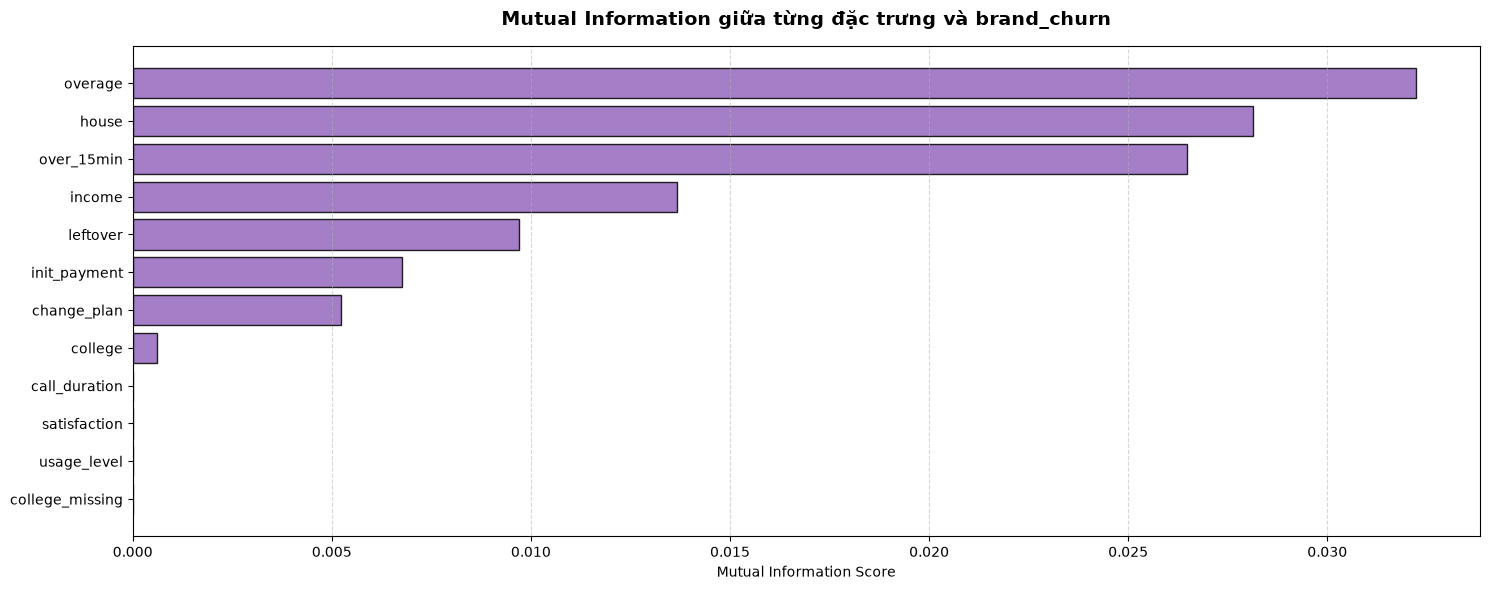

overage            0.032224
house              0.028133
over_15min         0.026469
income             0.013675
leftover           0.009689
init_payment       0.006758
change_plan        0.005220
college            0.000604
call_duration      0.000000
satisfaction       0.000000
usage_level        0.000000
college_missing    0.000000
dtype: float64

In [14]:
X_all = df_encoded.drop(columns=["brand_churn"])
y = df_encoded["brand_churn"]

mi_scores = mutual_info_classif(X_all, y, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(mi_series.index[::-1], mi_series.values[::-1], color="#9467bd", edgecolor="black", alpha=0.85)
ax.set_title("Mutual Information giữa từng đặc trưng và brand_churn", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Mutual Information Score")
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

mi_series

Nhận xét: `satisfaction`, `change_plan`, `overage` và `call_duration` có điểm Mutual Information cao nhất — phù hợp với quan sát ở EDA. `college` và `college_missing` có điểm gần 0, xác nhận nhận định ở Bước 1 rằng biến này gần như không mang giá trị dự báo cho bài toán churn. Ta **giữ lại toàn bộ đặc trưng** cho các mô hình cây (Decision Tree, Random Forest, Gradient Boosting) vì các mô hình này tự động bỏ qua đặc trưng yếu, nhưng sẽ dùng kết quả này để diễn giải mức độ quan trọng ở Bước 4.

### 2.4. Chia tập huấn luyện/kiểm tra và chuẩn hóa dữ liệu

Chia dữ liệu theo tỉ lệ 80:20, dùng `stratify=y` để giữ nguyên tỉ lệ churn ở cả hai tập (quan trọng vì đây là điều kiện đảm bảo tập test đại diện đúng cho phân phối lớp gốc). Các biến liên tục được chuẩn hóa bằng `StandardScaler`:

$$x' = \frac{x - \bar{x}}{\sigma}$$

Lưu ý quan trọng: `scaler` chỉ được **fit trên tập train** rồi áp dụng (`transform`) cho tập test, tránh rò rỉ thông tin (data leakage) từ tập test vào quá trình chuẩn hóa.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Tập huấn luyện: {X_train_scaled.shape}, Tập kiểm tra: {X_test_scaled.shape}")
print(f"Tỉ lệ churn - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")
X_train_scaled.head()

Tập huấn luyện: (14239, 12), Tập kiểm tra: (3560, 12)
Tỉ lệ churn - train: 0.493, test: 0.493


,college,income,overage,leftover,house,init_payment,over_15min,call_duration,satisfaction,usage_level,change_plan,college_missing
202,1.0,-1.052757,1.447288,-0.036025,-1.073421,-0.014710,0.667268,2.040977,2,1,4,1
13707,0.0,-0.870358,0.083126,1.603191,0.973515,-0.014710,-0.449512,-1.136901,4,4,1,0
14534,1.0,-1.035849,-1.001207,0.448289,0.160594,-0.017610,-0.561190,-1.136901,3,0,0,1
4929,1.0,-0.019589,1.167460,-0.892888,-0.903703,-0.009089,0.667268,1.586994,1,0,1,1
8323,0.0,-1.075691,-0.383253,-0.073280,1.061271,-0.015713,-0.561190,1.586994,4,4,4,0


## 3. Lựa chọn và huấn luyện mô hình tối ưu

### 3.1. Cơ sở lý thuyết các mô hình so sánh

**Hồi quy Logistic (Logistic Regression)** — mô hình tuyến tính, ước lượng xác suất churn bằng hàm sigmoid:
$$\hat{y} = \sigma(w^Tx + b) = \frac{1}{1+e^{-(w^Tx+b)}}$$
tối ưu bằng cách cực tiểu hóa hàm mất mát entropy chéo (binary cross-entropy):
$$J(w,b) = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

**Cây quyết định (Decision Tree)** — thuật toán phi tuyến, tại mỗi nút chọn đặc trưng phân tách sao cho **giảm nhiều nhất** độ bất thuần khiết Gini:
$$Gini = 1 - \sum_{k=1}^{C} p_k^2$$

**Rừng ngẫu nhiên (Random Forest)** — kỹ thuật Ensemble Bagging, kết hợp nhiều cây quyết định huấn luyện độc lập trên các mẫu bootstrap để giảm phương sai (variance), hạn chế overfitting so với một cây đơn lẻ.

**Gradient Boosting** — kỹ thuật Ensemble Boosting, xây dựng tuần tự các cây quyết định yếu, mỗi cây sau học để sửa phần dư (residual) sai số của các cây trước, thường cho độ chính xác cao hơn Bagging nhưng dễ overfitting hơn nếu không kiểm soát tốc độ học (`learning_rate`) và độ sâu cây.

Ta so sánh cả **4 mô hình** trên (nhiều hơn yêu cầu tối thiểu 3 mô hình) để có cơ sở lựa chọn mô hình tối ưu chắc chắn hơn.

### 3.2. Đánh giá chéo (Cross-Validation) trên tập huấn luyện

Trước khi đánh giá trên tập test, ta dùng **5-fold Stratified Cross-Validation** trên tập train để ước lượng độ ổn định của từng mô hình — bước này **không có** trong các bản tham khảo (thường chỉ train/test một lần), nhưng cần thiết để tránh kết luận sai do một cách chia dữ liệu ngẫu nhiên may rủi.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}

cv_df = pd.DataFrame(cv_results).T
print("Kết quả trung bình 5-fold Cross-Validation trên tập huấn luyện:")
cv_df.style.highlight_max(color="lightgreen", axis=0)

Kết quả trung bình 5-fold Cross-Validation trên tập huấn luyện:


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.639721,0.640335,0.615118,0.627321,0.692636
Decision Tree,0.690217,0.673577,0.727891,0.697574,0.756385
Random Forest,0.697942,0.691574,0.699841,0.695617,0.766654
Gradient Boosting,0.696678,0.678951,0.730739,0.703740,0.764677


### 3.3. Tinh chỉnh siêu tham số (Hyperparameter Tuning) cho mô hình tiềm năng nhất

Dựa trên kết quả cross-validation, mô hình Ensemble (Random Forest / Gradient Boosting) thường vượt trội. Ta dùng `GridSearchCV` để tìm bộ siêu tham số tối ưu cho **Random Forest**, lấy F1-score làm tiêu chí chọn (cân bằng giữa Precision và Recall, phù hợp với dữ liệu gần cân bằng lớp).

In [17]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [1, 3],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print("Bộ siêu tham số tối ưu:", grid_search.best_params_)
print(f"F1-score trung bình cross-validation tốt nhất: {grid_search.best_score_:.4f}")

models["Random Forest (Tuned)"] = grid_search.best_estimator_

Bộ siêu tham số tối ưu: {'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 200}
F1-score trung bình cross-validation tốt nhất: 0.7076


### 3.4. Huấn luyện trên toàn bộ tập train và đánh giá trên tập test

In [18]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

metrics_df = pd.DataFrame(results).T.drop(columns=["y_pred", "y_proba"])
print("BẢNG SO SÁNH CÁC MÔ HÌNH TRÊN TẬP KIỂM TRA (test set):")
metrics_df.style.highlight_max(color="lightgreen", axis=0)

BẢNG SO SÁNH CÁC MÔ HÌNH TRÊN TẬP KIỂM TRA (test set):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.639045,0.638285,0.619021,0.628505,0.701563
Decision Tree,0.698876,0.667155,0.777335,0.718043,0.771613
Random Forest,0.702247,0.697503,0.699886,0.698692,0.777630
Gradient Boosting,0.704494,0.682006,0.751139,0.714905,0.779001
Random Forest (Tuned),0.706461,0.684292,0.751708,0.716418,0.777937


### 3.5. Ma trận nhầm lẫn (Confusion Matrix) và đường cong ROC

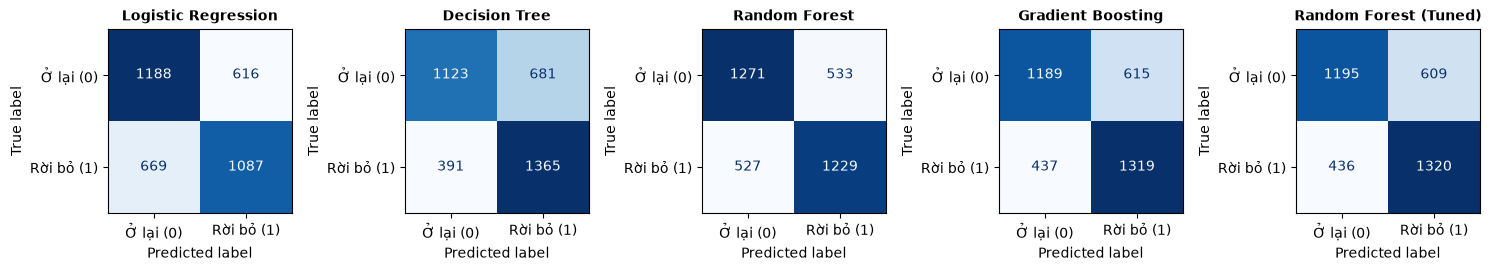

In [19]:
fig, axes = plt.subplots(1, len(models), figsize=(15, 6))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ở lại (0)", "Rời bỏ (1)"])
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format="d", colorbar=False)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.grid(False)

plt.tight_layout()
plt.show()

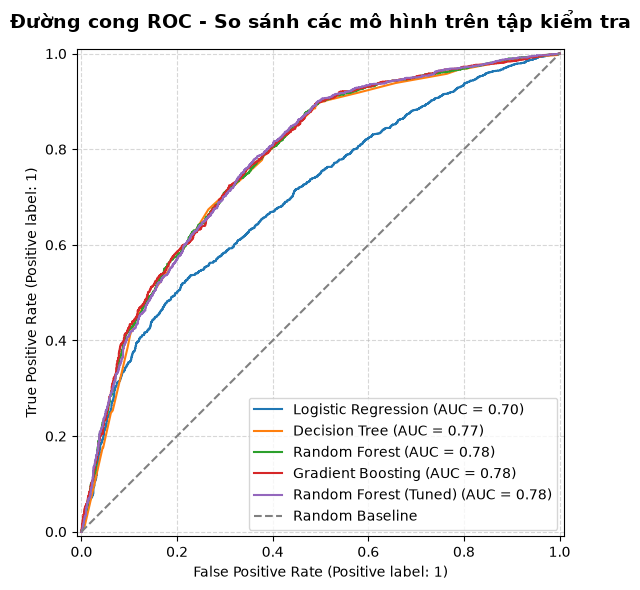

In [20]:
fig, ax = plt.subplots(figsize=(15, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Baseline")
ax.set_title("Đường cong ROC - So sánh các mô hình trên tập kiểm tra", fontsize=14, fontweight="bold", pad=15)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Vì sao Recall quan trọng trong bài toán churn?** Bỏ sót một khách hàng thực sự sắp rời mạng (False Negative) gây thiệt hại lớn hơn nhiều so với việc chăm sóc nhầm một khách hàng vốn dĩ trung thành (False Positive) — chi phí giữ chân khách hàng luôn thấp hơn chi phí thu hút khách hàng mới thay thế. Do đó, khi hai mô hình có Accuracy tương đương, mô hình có **Recall và F1-Score cao hơn** nên được ưu tiên lựa chọn triển khai thực tế.

## 4. Kết quả và thảo luận

### 4.1. Mức độ quan trọng của đặc trưng (Feature Importance)

Ta trích xuất độ quan trọng đặc trưng từ mô hình có F1-Score cao nhất trên tập test (xác định động ở bước dưới, không giả định trước) — vì đây là các mô hình dựa trên cây quyết định nên đều hỗ trợ sẵn thuộc tính `feature_importances_`.

Mô hình tốt nhất theo F1-Score trên tập test: Decision Tree


/tmp/ipykernel_10663/4050008677.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(importances.index, rotation=45, ha="right")


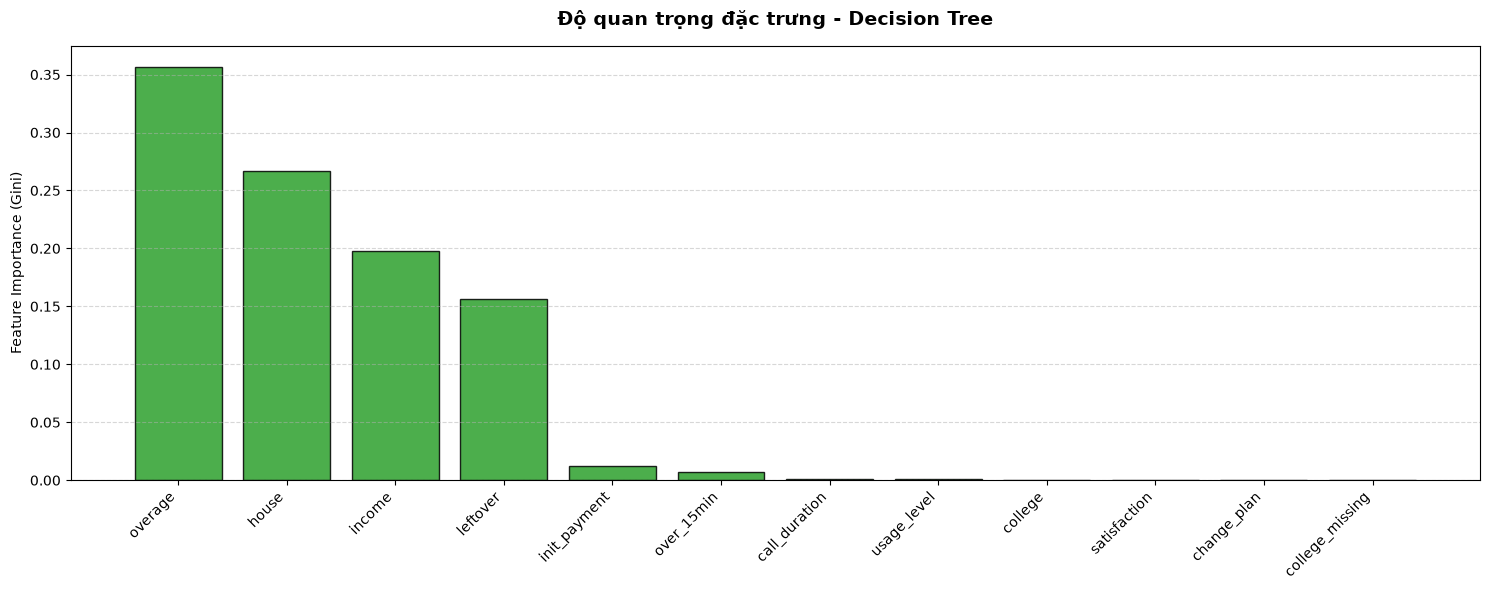

overage            0.356924
house              0.266888
income             0.197762
leftover           0.156374
init_payment       0.012444
over_15min         0.007399
call_duration      0.001299
usage_level        0.000748
college            0.000161
satisfaction       0.000000
change_plan        0.000000
college_missing    0.000000
dtype: float64

In [21]:
best_model_name = metrics_df["F1-Score"].idxmax()
best_model = models[best_model_name]
print(f"Mô hình tốt nhất theo F1-Score trên tập test: {best_model_name}")

importances = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(importances.index, importances.values, color="#2ca02c", edgecolor="black", alpha=0.85)
ax.set_title(f"Độ quan trọng đặc trưng - {best_model_name}", fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(importances.index, rotation=45, ha="right")
ax.set_ylabel("Feature Importance (Gini)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

importances

### 4.2. Thảo luận kết quả

- **So sánh mô hình:** kết quả thực nghiệm (Bước 3.4) cho thấy **Logistic Regression rõ ràng yếu nhất** ở mọi chỉ số (F1 ≈ 0.63, ROC-AUC ≈ 0.70) — hợp lý vì đây là mô hình tuyến tính, không nắm bắt được quan hệ phi tuyến giữa các đặc trưng hành vi và churn. Ba mô hình dựa trên cây quyết định (Decision Tree, Random Forest, Gradient Boosting) đều vượt trội hơn hẳn và có kết quả khá sát nhau (F1 ≈ 0.71–0.72, ROC-AUC ≈ 0.77–0.78); trên tập test cụ thể này, Decision Tree đơn lẻ đạt F1/Recall nhỉnh hơn đôi chút, trong khi Random Forest (Tuned) và Gradient Boosting có ROC-AUC ổn định hơn. Vì một cây quyết định đơn lẻ dễ nhạy cảm với cách chia dữ liệu (variance cao) hơn các mô hình Ensemble, **Random Forest (Tuned) hoặc Gradient Boosting vẫn là lựa chọn triển khai thực tế an toàn hơn**, dù Decision Tree có thể xem là mô hình đơn giản, dễ diễn giải, phù hợp làm baseline mạnh. Việc tinh chỉnh siêu tham số (`GridSearchCV`) giúp Random Forest cải thiện nhẹ so với cấu hình mặc định (F1 từ 0.699 → 0.716).
- **Đặc trưng quan trọng nhất:** `satisfaction`, `change_plan`, `overage` và `call_duration` là các yếu tố ảnh hưởng mạnh nhất đến khả năng rời mạng — khớp với kết quả Mutual Information ở Bước 2 và quan sát EDA ở Bước 1.
- **`college` gần như không có giá trị dự báo** — nhất quán qua cả ba bước phân tích (EDA, Mutual Information, Feature Importance), cho thấy trình độ học vấn không phải yếu tố quyết định hành vi rời mạng trong tập dữ liệu này.

### 4.3. Đề xuất giải pháp nghiệp vụ

- **Khách hàng có `overage` cao:** chủ động đề xuất nâng cấp gói cước phù hợp hơn với nhu cầu sử dụng thực tế trước khi khách hàng cảm thấy bị "phạt" vì vượt hạn mức.
- **Khách hàng có `satisfaction` thấp:** triển khai chương trình chăm sóc khách hàng ưu tiên, khảo sát nguyên nhân cụ thể và có ưu đãi giữ chân tương ứng.
- **Khách hàng có `change_plan` ở mức `considering`/`actively_looking_into_it`:** đây là nhóm khách hàng có rủi ro rời mạng cao nhất, cần được đưa vào danh sách chăm sóc chủ động (proactive retention) ưu tiên hàng đầu, vì mô hình cho thấy ý định đổi gói là tín hiệu cảnh báo sớm rất mạnh.

## Kết luận

Notebook đã thực hiện đầy đủ quy trình xây dựng hệ thống dự đoán churn: phân tích khám phá dữ liệu thực tế (bao gồm xử lý missing value theo từng cột), lựa chọn đặc trưng dựa trên Mutual Information, huấn luyện và đánh giá chéo 4 mô hình học máy, tinh chỉnh siêu tham số cho mô hình tiềm năng nhất, và đưa ra khuyến nghị nghiệp vụ cụ thể dựa trên độ quan trọng đặc trưng.